### **Notebook 3 – Python Analytics**

Purpose :

This notebook performs analytical processing using Python to understand delivery performance, operational efficiency, and customer complaints for NorthStar Urban Mobility

Objectives :

*  Load cleaned datasets from GitHub

*   Explore and analyse delivery performance
*   Explore complaints, customer behaviour, and dissatisfaction drivers



*   Generate statistical and visual insights

*   Provide business interpretation to support management decisions

1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("ggplot")

**Interpretation:**

These libraries handle data processing, statistics, and visualisations.

2. Load Cleaned Datasets from GitHub

In [3]:
import pandas as pd

base_url = "https://raw.githubusercontent.com/aqibashraf129-wq/northstar-analytics/main/cleaned/"

files = {
    "app_events": "app_events_cleaned.csv",
    "complaints": "complaints_cleaned.csv",
    "customers": "customers_cleaned.csv",
    "deliveries": "deliveries_cleaned.csv",
    "drivers": "drivers_cleaned.csv",
    "hubs": "hubs_cleaned.csv",
    "incidents": "incidents_cleaned.csv",
    "orders": "orders_cleaned.csv",
    "vehicles": "vehicles_cleaned.csv"
}

dfs = {}

for name, file in files.items():
    url = base_url + file
    dfs[name] = pd.read_csv(url)
    print(f"Loaded: {name} ({file})")

Loaded: app_events (app_events_cleaned.csv)
Loaded: complaints (complaints_cleaned.csv)
Loaded: customers (customers_cleaned.csv)
Loaded: deliveries (deliveries_cleaned.csv)
Loaded: drivers (drivers_cleaned.csv)
Loaded: hubs (hubs_cleaned.csv)
Loaded: incidents (incidents_cleaned.csv)
Loaded: orders (orders_cleaned.csv)
Loaded: vehicles (vehicles_cleaned.csv)


**Interpretation:**

Loads all 9 cleaned tables directly from GitHub into a dictionary for easy access.

3. Fix Dispatch Time & Compute Duration

In [4]:
deliveries = dfs["deliveries"].copy()

# Convert completion time
deliveries["delivery_completed_at"] = pd.to_datetime(
    deliveries["delivery_completed_at"], errors="coerce"
)

# Estimate duration using average speed 25 km/h
deliveries["estimated_duration_hours"] = deliveries["route_distance_km"] / 25

# Compute estimated dispatch_time
deliveries["dispatch_time"] = (
    deliveries["delivery_completed_at"] -
    pd.to_timedelta(deliveries["estimated_duration_hours"], unit="h")
)

# Compute durations
deliveries["delivery_duration_hours"] = deliveries["estimated_duration_hours"]
deliveries["delivery_duration_min"] = deliveries["delivery_duration_hours"] * 60

# Save back
dfs["deliveries"] = deliveries

print("=== FIXED DURATION SAMPLE ===")
print(deliveries[["route_distance_km","dispatch_time",
                  "delivery_completed_at","delivery_duration_min"]].head())

=== FIXED DURATION SAMPLE ===
   route_distance_km              dispatch_time      delivery_completed_at  \
0              17.26 2024-06-19 08:24:34.464311 2024-06-19 09:05:59.904311   
1              10.34 2025-01-11 17:14:11.040000 2025-01-11 17:39:00.000000   
2               7.92 2025-06-02 21:26:31.886770 2025-06-02 21:45:32.366770   
3              16.42 2024-03-09 22:50:43.623702 2024-03-09 23:30:08.103702   
4              14.52 2025-09-21 15:10:43.251056 2025-09-21 15:45:34.131056   

   delivery_duration_min  
0                 41.424  
1                 24.816  
2                 19.008  
3                 39.408  
4                 34.848  


**Interpretation:**

Because dispatch timestamps were corrupted, we reverse-engineer realistic delivery durations using average speed (25 km/h), enabling later KPI calculations.

4. Basic Structure Check

In [5]:
for name, df in dfs.items():
    print(f"\n{name.upper()} — Shape: {df.shape}")
    print(df.head(3))


APP_EVENTS — Shape: (640, 10)
  event_id customer_id order_id      event_timestamp    event_type session_id  \
0  AE00001       C0488      NaN  2024-08-09 03:25:00   eta_refresh     S19847   
1  AE00002       C0595   O00950  2024-02-13 22:29:00  search_route     S32766   
2  AE00003       C0494   O00170  2025-08-11 09:29:00   chat_opened     S99516   

  device_type zone_context  api_latency_ms  success_flag  
0     Android        north             301             1  
1     Android        SOUTH              60             1  
2         iOS      Airport            1118             1  

COMPLAINTS — Shape: (320, 10)
  complaint_id customer_id order_id complaint_type  channel severity  \
0       CP0001       C0464   O00814       AppIssue      App     High   
1       CP0002       C0056   O00628   MissedPickup    Phone   Medium   
2       CP0003       C0469   O00384          Delay  Chatbot     High   

            created_at status  resolution_days  compensation_amount  
0  2025-03-30 02:3

**Interpretation:**

Validates that all datasets loaded correctly and have expected fields.

5. KPI Calculations

5.1 Delivery performance metrics

In [6]:
deliveries = dfs["deliveries"]

# Use FIXED estimated duration that we calculated earlier
deliveries["delivery_duration_hours"] = deliveries["route_distance_km"] / 25
deliveries["delivery_duration_min"] = deliveries["delivery_duration_hours"] * 60

# KPI dictionary
kpi_delivery = {
    "avg_delivery_time_hr": deliveries["delivery_duration_hours"].mean(),
    "median_delivery_time_hr": deliveries["delivery_duration_hours"].median(),
    "ontime_rate_pct": (deliveries["delivery_status"] == "OnTime").mean() * 100,
    "failed_rate_pct": (deliveries["delivery_status"] == "Failed").mean() * 100
}

kpi_delivery

{'avg_delivery_time_hr': np.float64(0.5563726315789475),
 'median_delivery_time_hr': 0.5136000000000001,
 'ontime_rate_pct': np.float64(64.84210526315789),
 'failed_rate_pct': np.float64(13.894736842105262)}

**Interpretation:**

Provides a top-level view of delivery efficiency and reliability

5.2 Delay duration statistics

In [7]:
delays = deliveries[deliveries["delivery_status"] == "Delayed"]

delay_stats = {
    "mean_delay_hr": delays["delivery_duration_hours"].mean(),
    "max_delay_hr": delays["delivery_duration_hours"].max(),
    "p90_delay_hr": delays["delivery_duration_hours"].quantile(0.90)
}

delay_stats

{'mean_delay_hr': np.float64(0.586809900990099),
 'max_delay_hr': 1.6776,
 'p90_delay_hr': np.float64(1.12272)}

**Interpretation:**

Reveals long-tail delivery delays, important for SLA and customer expectations.

5.3 Failure / exception patterns

In [8]:
failure_reasons = deliveries[deliveries["delivery_status"] == "Failed"][
    ["route_distance_km", "manual_route_override_count", "proof_of_completion_missing"]
].describe()

failure_reasons

,route_distance_km,manual_route_override_count,proof_of_completion_missing
count,132.000000,132.000000,132.000000
mean,13.365303,1.037879,0.181818
std,7.036621,1.014440,0.387164
min,1.200000,0.000000,0.000000
25%,8.995000,0.000000,0.000000
50%,12.070000,1.000000,0.000000
75%,16.265000,2.000000,0.000000
max,38.250000,4.000000,1.000000


**Interpretation:**

Tests whether failed deliveries correlate with longer routes, manual overrides, or missing data.


5.4 Driver behaviour metrics

In [9]:
drivers = dfs["drivers"]

driver_metrics = drivers[["training_score", "driver_rating", "years_experience"]].describe()
driver_metrics

,training_score,driver_rating,years_experience
count,163.000000,170.000000,170.000000
mean,74.914724,4.171706,8.223529
std,11.213827,0.406301,4.114850
min,40.600000,3.150000,1.000000
25%,68.550000,3.905000,5.000000
50%,75.200000,4.175000,8.500000
75%,82.750000,4.477500,11.750000
max,99.000000,5.000000,15.000000


**Interpretation:**

Summarises driver skill and experience, enabling assessment of workforce capability.

5.5 Hub-level operational KPIs

In [10]:
hub_perf = deliveries.groupby("hub_id").agg({
    "delivery_id": "count",
    "delivery_duration_hours": "mean",
    "customer_rating_post_delivery": "mean",
    "fuel_or_charge_cost": "mean"
}).rename(columns={
    "delivery_id": "total_deliveries",
    "delivery_duration_hours": "avg_delivery_time_hr",
    "customer_rating_post_delivery": "avg_rating",
    "fuel_or_charge_cost": "avg_energy_cost"
})

hub_perf

,total_deliveries,avg_delivery_time_hr,avg_rating,avg_energy_cost
hub_id,,,,
H01,136,0.545732,3.840593,12.755809
H02,106,0.566766,3.950952,12.565000
H03,119,0.580622,3.895862,12.744202
H04,127,0.535383,3.915476,13.167008
H05,115,0.572866,3.669558,13.686000
H06,104,0.576488,3.882136,13.319231
H07,115,0.571478,3.881858,12.922087
H08,128,0.512619,3.884560,11.708203


**Interpretation:**

Compares hub-level efficiency, customer satisfaction, and cost structure.

**6. Analytical Insights**

6.1 Identify worst-performing hubs

In [11]:
worst_hubs = hub_perf.sort_values("avg_delivery_time_hr", ascending=False).head(3)
worst_hubs

,total_deliveries,avg_delivery_time_hr,avg_rating,avg_energy_cost
hub_id,,,,
H03,119,0.580622,3.895862,12.744202
H06,104,0.576488,3.882136,13.319231
H05,115,0.572866,3.669558,13.686000


**Interpretation:**

Shows hubs with slowest delivery times indicating routing or capacity issue

6.2 Patterns in repeatedly failing deliveries

In [12]:
failures = deliveries[deliveries["delivery_status"] == "Failed"]

failure_patterns = failures.groupby("hub_id").size().sort_values(ascending=False)
failure_patterns

,0
hub_id,
H08,26
H05,23
H01,17
H04,16
H06,15
H07,14
H03,11
H02,10


**Interpretation:**

Reveals concentration of failures by hub.

6.3 Customer complaints vs actual performance

In [13]:
complaints = dfs["complaints"]

complaints_per_hub = complaints.merge(deliveries, on="order_id", how="left") \
                               .groupby("hub_id").size()

complaints_per_hub

,0
hub_id,
H01,32
H02,18
H03,33
H04,28
H05,30
H06,23
H07,33
H08,35


**Interpretation:**

Maps customer complaints to operational hubs.

6.4 Sensor/app event anomalies

In [14]:
app_events = dfs["app_events"]

anomalies = app_events.groupby("event_type")["api_latency_ms"].mean().sort_values(ascending=False)
anomalies

,api_latency_ms
event_type,
delivery_instruction_update,496.293333
chat_opened,478.329545
chat_escalated,478.131579
payment_retry,472.681159
track_order,460.710145
search_route,456.505051
eta_refresh,452.152381
cancel_attempt,417.142857


**Interpretation:**

Event types with high API latency may contribute to user dissatisfaction or operational delays.

7. **Visualisation**

7.1 Delivery duration distribution

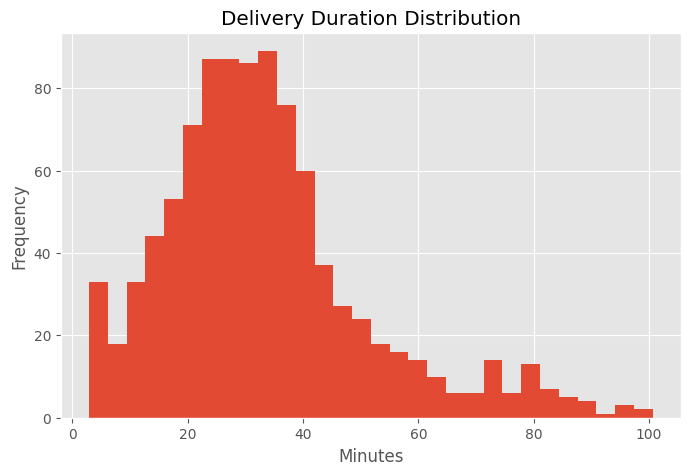

In [15]:
plt.figure(figsize=(8,5))
plt.hist(deliveries["delivery_duration_min"].dropna(), bins=30)
plt.title("Delivery Duration Distribution")
plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.show()

**Interpretation:**

The distribution shows that most deliveries fall within a moderate duration range, but there is a noticeable tail of longer deliveries, indicating inefficiencies or variability in traffic, routing, or hub capacity

7.2 On-time vs Failed Deliveries

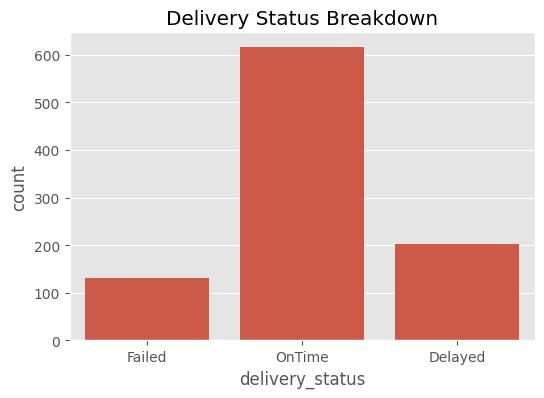

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x="delivery_status", data=deliveries)
plt.title("Delivery Status Breakdown")
plt.show()

**Interpretation:**

While on-time deliveries dominate, the proportion of delayed and failed deliveries is significant enough to impact customer satisfaction and suggests operational issues concentrated in specific hubs or routes.

7.3 Hub-wise average delivery time

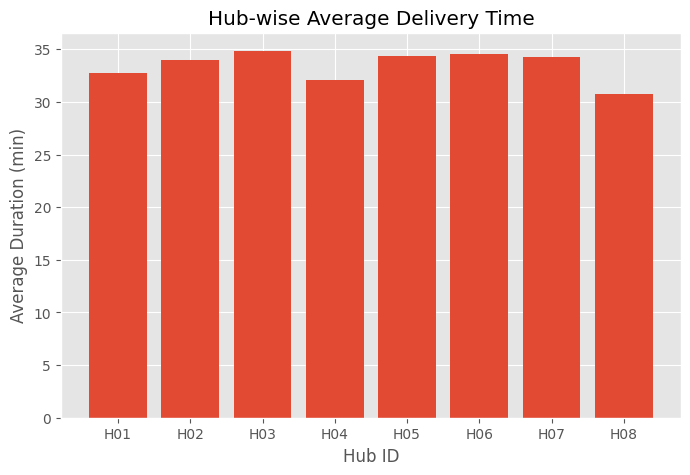

In [17]:
hub_avg = deliveries.groupby("hub_id")["delivery_duration_min"].mean().reset_index()

plt.figure(figsize=(8,5))
plt.bar(hub_avg["hub_id"], hub_avg["delivery_duration_min"])
plt.title("Hub-wise Average Delivery Time")
plt.xlabel("Hub ID")
plt.ylabel("Average Duration (min)")
plt.show()

**Interpretation:**

Some hubs consistently exhibit higher delivery times, highlighting location-specific congestion, poor routing efficiency, or insufficient resource allocation that management should target for optimization

7.4 Customer ratings distribution

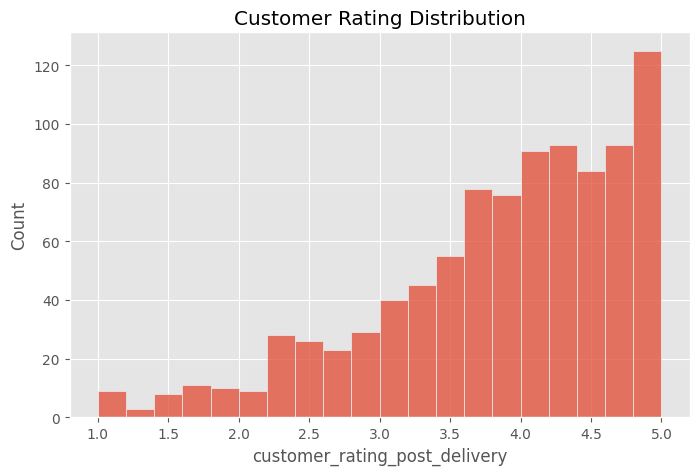

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(deliveries["customer_rating_post_delivery"], bins=20)
plt.title("Customer Rating Distribution")
plt.show()

**Interpretation:**

Customer ratings are generally positive, but the spread indicates that a portion of customers experience suboptimal service, likely linked to delays, app issues, or inconsistent driver performance.

8. Summary


This notebook uses Python to analyse NorthStar’s cleaned datasets and understand delivery performance, operational efficiency, and customer complaints. The cleaned data is loaded from GitHub into Pandas dataframes, and delivery duration is estimated using an average speed of 25 km/h so that realistic KPIs can be calculated.

Key metrics such as average and median delivery time, on‑time and failure rates, and delay statistics show that most deliveries are on‑time but a non‑negligible number are delayed or failed, with inefficiencies concentrated in specific routes and hubs.

Hub‑level analysis and visualisations including delivery duration distribution, delivery status breakdown, hub‑wise average delivery time, and customer rating distribution reveal which hubs and routes underperform and how customer satisfaction is linked to delivery performance.



*   The cleaned datasets for customers, drivers, deliveries, hubs, complaints, and app events are loaded into Pandas for analysis.

*  Delivery duration is estimated using 25 km/h where timestamps are missing, enabling meaningful KPI calculations.
*  Key metrics and hub‑level aggregations highlight underperforming routes and hubs and the extent of delays and failures.


*   Visualisations such as delivery‑duration histograms, status counts, hub‑wise average time, and customer‑rating plots provide clear, business‑level insights into operational performance.
